In [13]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
data = pd.read_csv("/content/drive/MyDrive/Statistic/flights.csv")
data.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


In [10]:
data["arr_delay"].mean()

np.float64(6.89537675731489)

In [11]:
data["arr_delay"]

,arr_delay
0,11.0
1,20.0
2,33.0
3,-18.0
4,-25.0
...,...
336771,NaN
336772,NaN
336773,NaN
336774,NaN


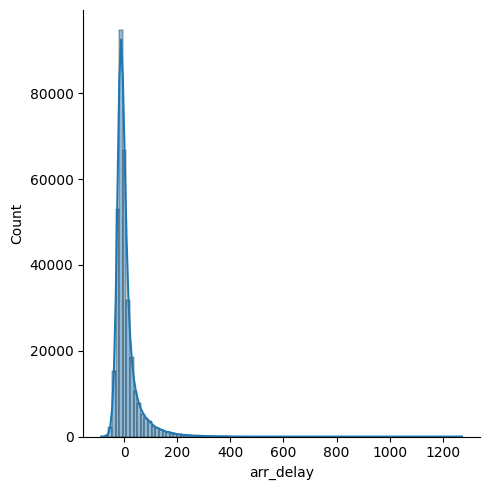

In [14]:
sns.displot(data["arr_delay"], bins = 100, kde = True)

In [15]:
stats.trim_mean(data["arr_delay"], 0.1)

np.float64(0.9612355338465307)

In [16]:
print(f"Median is {data["arr_delay"].median()}")
print(f"Mode is {data["arr_delay"].mode()}")
print(f"Variance is {data["arr_delay"].var()}")
print(f"STD is {data["arr_delay"].std()}")

Median is -5.0
Mode is 0   -13.0
Name: arr_delay, dtype: float64
Variance is 1992.130727102053
STD is 44.63329169019526


In [17]:
trim_data1 = data["arr_delay"][data["arr_delay"] < 100]

<Axes: >

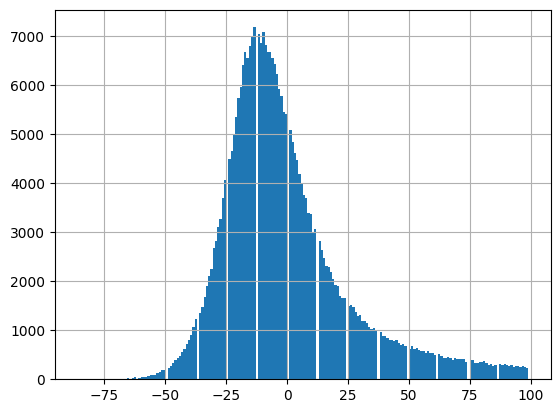

In [18]:
trim_data1.hist(bins=200)

In [19]:
print(f"Mean is {trim_data1.mean()}")
print(f"Median is {trim_data1.median()}")
print(f"Mode is {trim_data1.mode()}")
print(f"Variance is {trim_data1.var()}")
print(f"STD is {trim_data1.std()}")

Mean is -0.16569653274241908
Median is -6.0
Mode is 0   -13.0
Name: arr_delay, dtype: float64
Variance is 702.118464248494
STD is 26.49751807714251


In [20]:
Left_domain = trim_data1.mean() - 3 * trim_data1.std()
Right_domain = trim_data1.mean() + 3 * trim_data1.std()
print(f"Domain: [{Left_domain}, {Right_domain}]")

Domain: [-79.65825076416995, 79.32685769868512]


In [21]:
data1 = data["arr_delay"]

<Axes: >

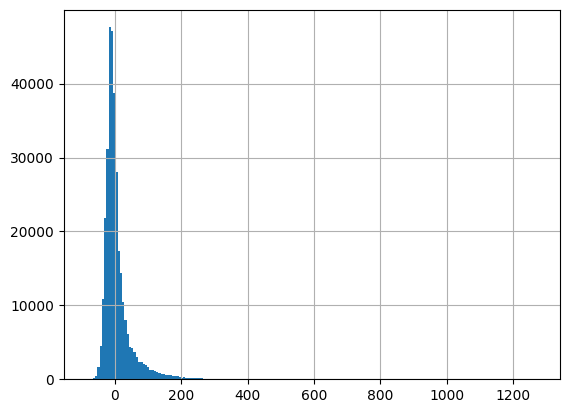

In [22]:
data1.hist(bins=200)

In [23]:
print(f"Mean is {data1.mean()}")
print(f"Median is {data1.median()}")
print(f"Mode is {data1.mode()}")
print(f"Variance is {data1.var()}")
print(f"STD is {data1.std()}")

Mean is 6.89537675731489
Median is -5.0
Mode is 0   -13.0
Name: arr_delay, dtype: float64
Variance is 1992.130727102053
STD is 44.63329169019526


In [25]:
print(f"Kurtosis:\n for Total data: {data1.kurtosis()} \n for Trim data: {trim_data1.kurtosis()}")

Kurtosis:
 for Total data: 29.233043998766775 
 for Trim data: 1.8353659662635664


In [26]:
print(f"Skewness:\n for Total data: {data1.skew()} \n for Trim data: {trim_data1.skew()}")

Skewness:
 for Total data: 3.7168174804571863 
 for Trim data: 1.2539179317586369


In [32]:
data.corr(numeric_only=True)

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,flight,air_time,distance,hour,minute
id,1.000000,NaN,0.071779,0.087852,0.002172,0.004076,0.049713,-0.024680,-0.013373,0.018613,0.002676,-0.032866,0.012526,0.003150,0.022619
year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,0.071779,NaN,1.000000,0.002942,-0.003932,-0.004573,-0.020057,-0.002520,-0.004173,-0.017382,-0.000834,0.010924,0.021636,-0.005227,0.015528
day,0.087852,NaN,0.002942,1.000000,-0.000467,-0.000014,0.000420,-0.005537,-0.002403,-0.000319,-0.001791,0.002236,0.003041,-0.000055,0.000987
dep_time,0.002172,NaN,-0.003932,-0.000467,1.000000,0.954617,0.260231,0.660779,0.784682,0.232306,0.041957,-0.014619,-0.013998,0.953306,0.091577
sched_dep_time,0.004076,NaN,-0.004573,-0.000014,0.954617,1.000000,0.198887,0.642680,0.783342,0.173896,0.036495,-0.015532,-0.017995,0.999148,0.082960
dep_delay,0.049713,NaN,-0.020057,0.000420,0.260231,0.198887,1.000000,0.028729,0.160488,0.914803,0.054734,-0.022405,-0.021671,0.198226,0.028441
arr_time,-0.024680,NaN,-0.002520,-0.005537,0.660779,0.642680,0.028729,1.000000,0.788997,0.024482,0.025042,0.054296,0.046991,0.642651,0.040969
sched_arr_time,-0.013373,NaN,-0.004173,-0.002403,0.784682,0.783342,0.160488,0.788997,1.000000,0.133261,0.021594,0.078918,0.068726,0.783283,0.050321
arr_delay,0.018613,NaN,-0.017382,-0.000319,0.232306,0.173896,0.914803,0.024482,0.133261,1.000000,0.072862,-0.035297,-0.061868,0.173456,0.021522
